Data loaded successfully with shape: (640, 96)
Target variable 'B2' encoded successfully.
Calculating Correlation Analysis...


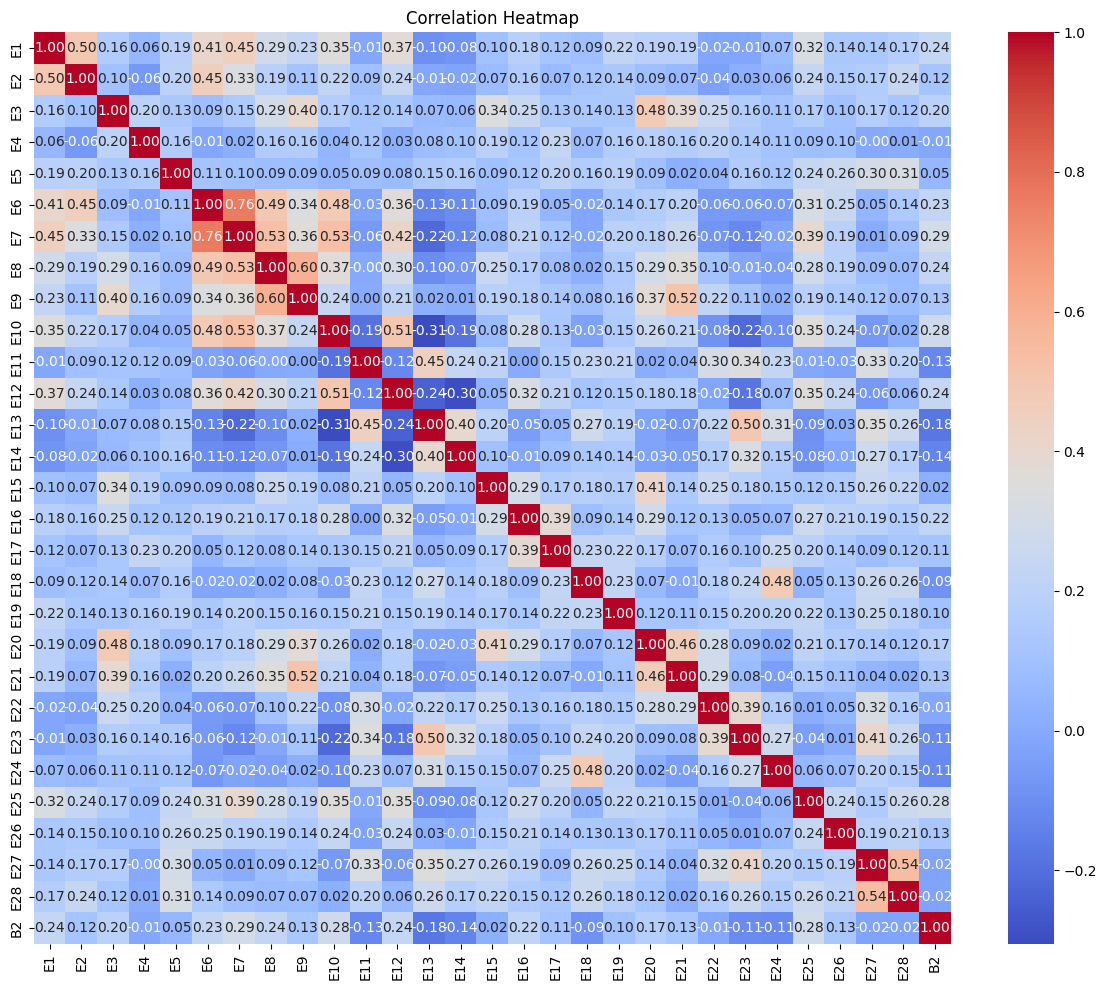

Correlation heatmap saved as 'correlation_heatmap.png'.
Calculating Mutual Information...


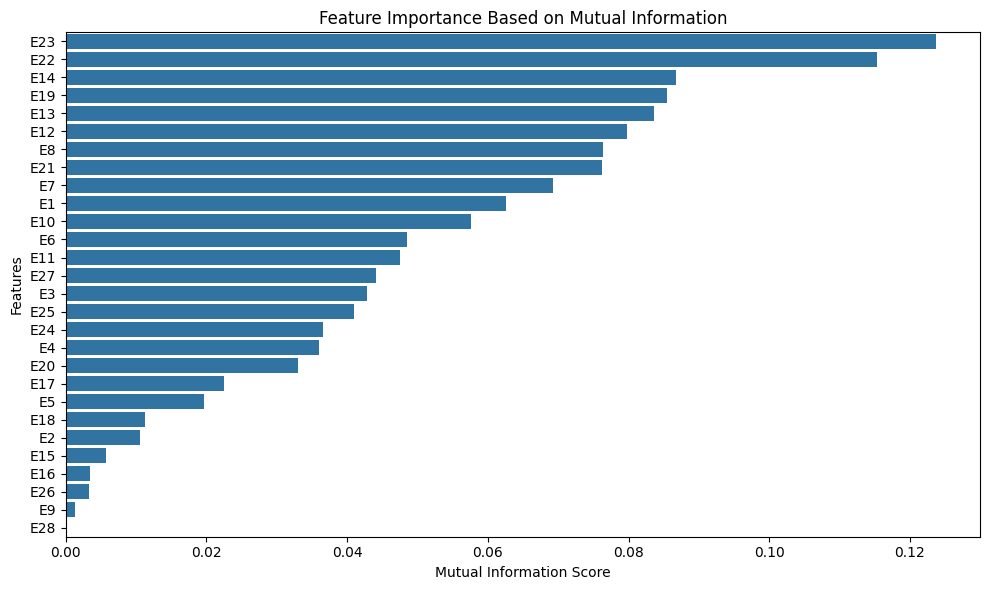

Mutual Information graph saved as 'mutual_information_importance.png'.
E23    0.123768
E22    0.115269
E14    0.086811
E19    0.085454
E13    0.083644
dtype: float64
Calculating Random Forest feature importance...


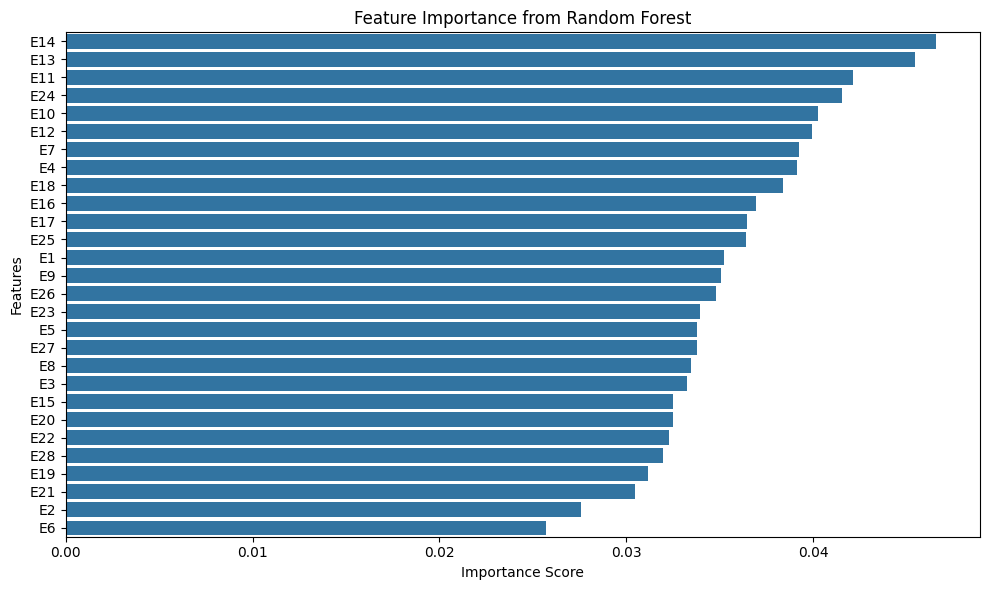

Random Forest graph saved as 'random_forest_importance.png'.
E14    0.046603
E13    0.045464
E11    0.042123
E24    0.041553
E10    0.040277
dtype: float64
Calculating XGBoost feature importance...


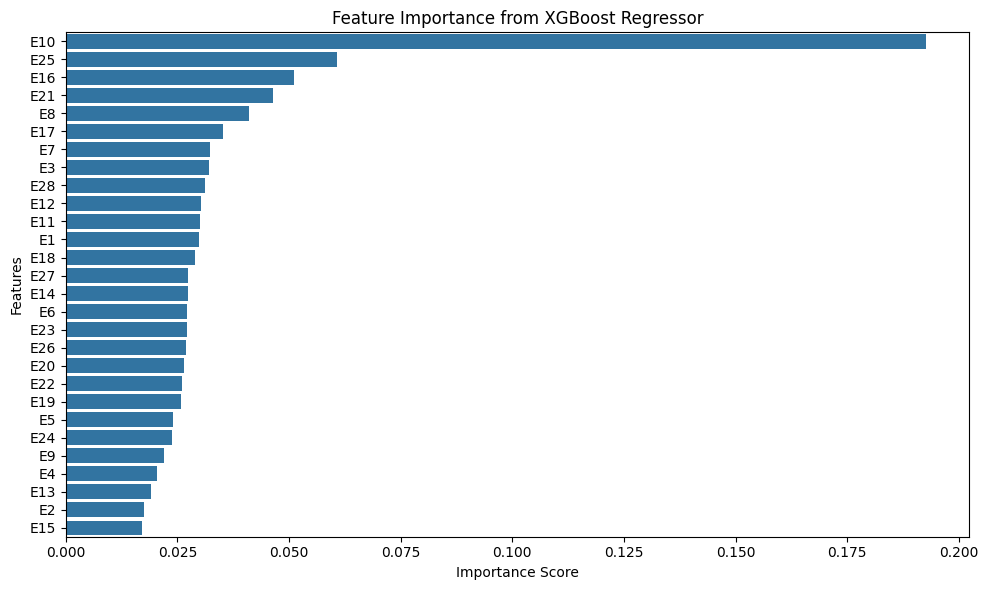

XGBoost graph saved as 'xgboost_importance.png'.
E10    0.192598
E25    0.060826
E16    0.051087
E21    0.046481
E8     0.041083
dtype: float32
Calculating Permutation Importance...


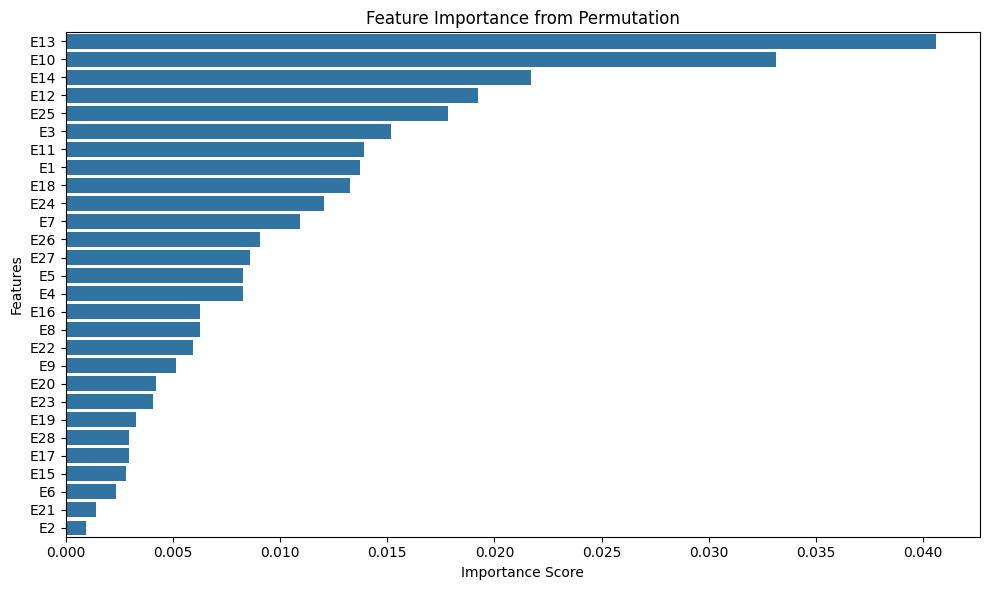

Permutation Importance graph saved as 'permutation_importance.png'.
Calculating SHAP values...


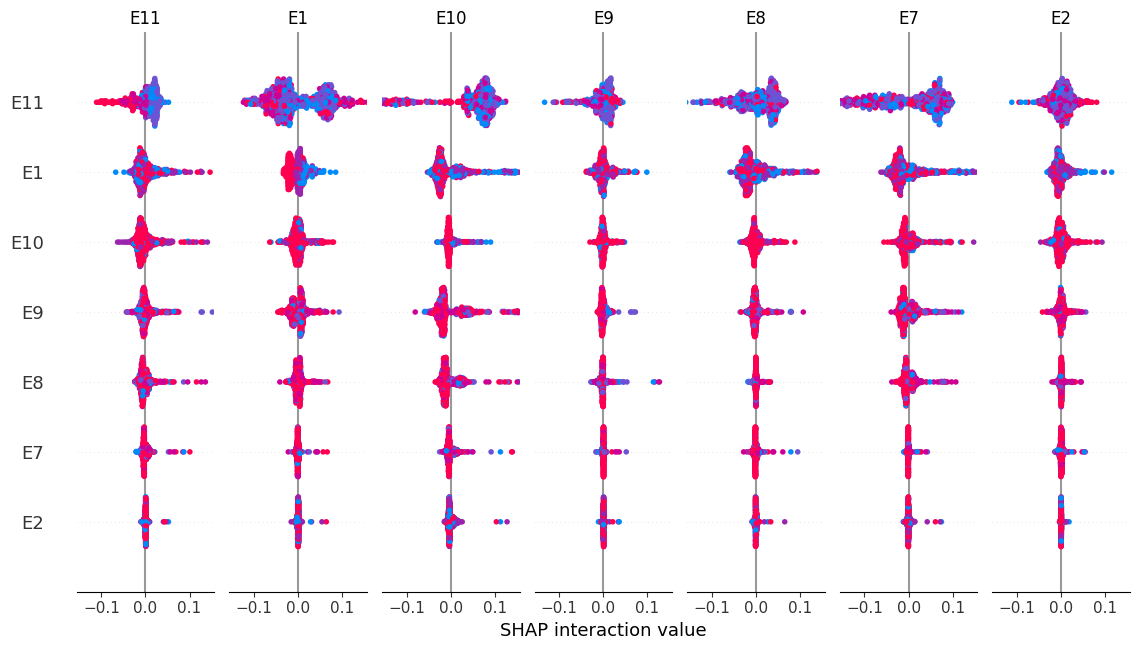

SHAP importance plot saved as 'shap_importance.png'.
Evaluating Feature Importance Stability...


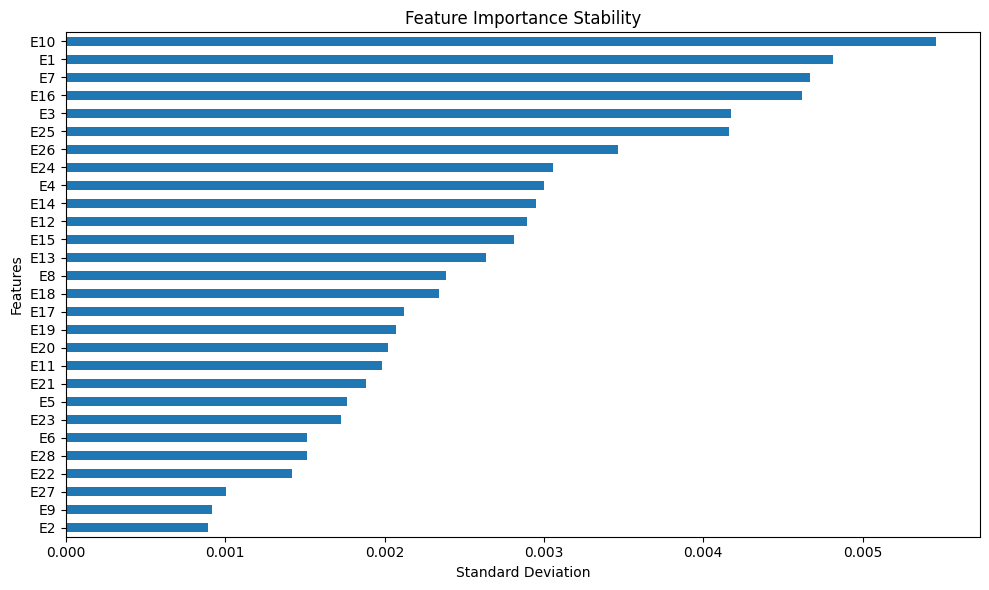

Feature importance stability plot saved as 'feature_importance_stability.png'.
Aggregating Rankings...


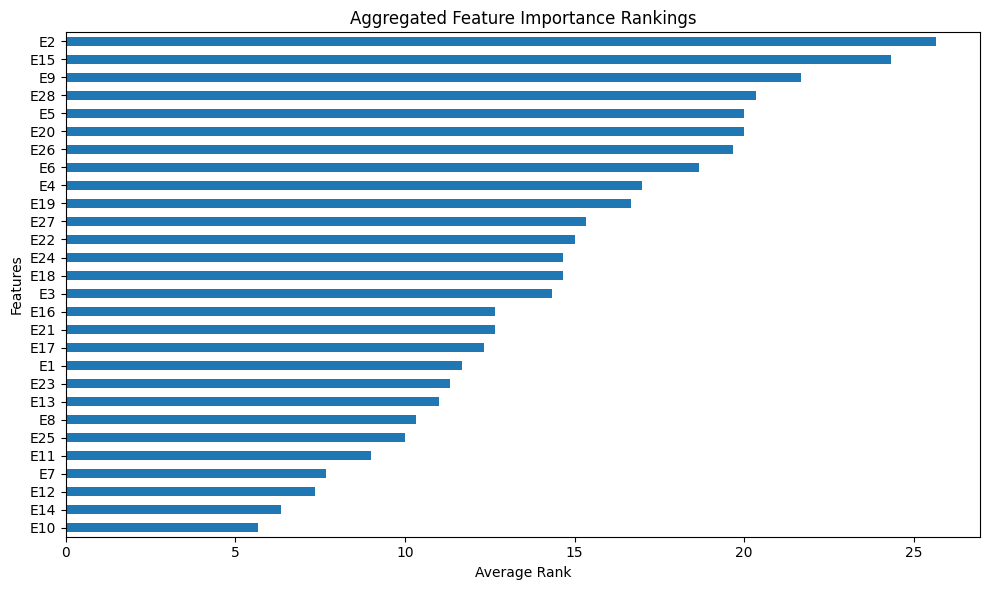

Aggregated feature importance plot saved as 'aggregated_importance.png'.
Data loaded successfully with shape: (640, 96)


NameError: name 'mapping' is not defined

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import shap
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def load_data(file_path, encoding='ISO-8859-1'):
    """
    Load the dataset and return it as a DataFrame.
    """
    try:
        data = pd.read_csv(file_path, encoding=encoding)
        print(f"Data loaded successfully with shape: {data.shape}")
        return data
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def preprocess_data(data, behavior_columns):
    """
    Preprocess the data: scale numeric columns and handle missing values.
    """
    scaler = StandardScaler()
    X = pd.DataFrame(scaler.fit_transform(data[behavior_columns]), columns=behavior_columns)
    return X

def preprocess_target(data, target_col):
    """
    Convert string duration categories in the target column to numeric values.
    """
    mapping = {
        "No self-isolation/social distancing": 0,  # No isolation
        "1 day": 1,
        "3 days": 3,
        "4 days": 4,
        "5 days": 5,
        "6 days": 6,
        "7 days": 7,
        "More than a week": 8,  # Approximation for "More than a week"
        "More than 2 weeks": 15,
        "More than 3 weeks": 22,
        "More than a month": 32
    }

    if data[target_col].dtype == 'object':
        data[target_col] = data[target_col].map(mapping)

    # Identify unmapped values
    unmapped_values = data[target_col].isnull()
    if unmapped_values.sum() > 0:
        print(f"Warning: {unmapped_values.sum()} rows have unmapped values in '{target_col}'.")
        print("Unmapped values:")
        print(data.loc[unmapped_values, target_col])

    # Optionally drop rows with unmapped values
    data = data.dropna(subset=[target_col])
    return data[target_col]



def encode_target(data, target_col):
    """
    Encode the target variable using LabelEncoder.
    """
    label_encoder = LabelEncoder()
    return label_encoder.fit_transform(data[target_col])

def calculate_mutual_info(X, y, behavior_columns):
    """
    Calculate and visualize Mutual Information scores.
    """
    mutual_info = mutual_info_classif(X, y, discrete_features=False, n_neighbors=5)
    mi_scores = pd.Series(mutual_info, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=mi_scores.values, y=mi_scores.index)
    plt.title('Feature Importance Based on Mutual Information')
    plt.xlabel('Mutual Information Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('mutual_information_importance.png')
    plt.show()
    print("Mutual Information graph saved as 'mutual_information_importance.png'.")
    return mi_scores

def calculate_random_forest_importance(X, y, behavior_columns):
    """
    Calculate and visualize feature importance using Random Forest.
    """
    model = RandomForestClassifier(random_state=42, n_jobs=-1)
    model.fit(X, y)
    feature_importances = pd.Series(model.feature_importances_, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index)
    plt.title('Feature Importance from Random Forest')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('random_forest_importance.png')
    plt.show()
    print("Random Forest graph saved as 'random_forest_importance.png'.")
    return feature_importances

def calculate_xgboost_importance(X, y, behavior_columns):
    """
    Calculate and visualize feature importance using XGBoost Regressor.
    """
    model = XGBRegressor(eval_metric='rmse', n_jobs=-1)
    model.fit(X, y)
    feature_importances = pd.Series(model.feature_importances_, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=feature_importances.values, y=feature_importances.index)
    plt.title('Feature Importance from XGBoost Regressor')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('xgboost_importance.png')
    plt.show()
    print("XGBoost graph saved as 'xgboost_importance.png'.")
    return feature_importances

def calculate_permutation_importance(model, X, y, behavior_columns):
    """
    Calculate Permutation Importance after fitting a model.
    """
    result = permutation_importance(model, X, y, n_repeats=10, random_state=42, n_jobs=-1)
    perm_importances = pd.Series(result.importances_mean, index=behavior_columns).sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=perm_importances.values, y=perm_importances.index)
    plt.title('Feature Importance from Permutation')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('permutation_importance.png')
    plt.show()
    print("Permutation Importance graph saved as 'permutation_importance.png'.")
    return perm_importances

def calculate_correlation(data, target_col):
    """
    Calculate and visualize the correlation matrix.
    """
    if target_col not in data.columns:
        raise KeyError(f"{target_col} not found in the dataset.")
    corr_matrix = data.corr()
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.tight_layout()
    plt.savefig('correlation_heatmap.png')
    plt.show()
    print("Correlation heatmap saved as 'correlation_heatmap.png'.")

def calculate_shap_importance(X, y):
    """
    Calculate and visualize SHAP values.
    """
    model = RandomForestClassifier(random_state=42)
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, X, show=False)
    plt.tight_layout()
    plt.savefig('shap_importance.png')
    plt.show()
    print("SHAP importance plot saved as 'shap_importance.png'.")

def evaluate_feature_stability(X, y, behavior_columns, n_splits=5):
    """
    Evaluate feature importance stability across multiple splits.
    """
    rf_importances = []
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_index, test_index in kf.split(X):
        model = RandomForestClassifier(random_state=42)
        model.fit(X.iloc[train_index], y[train_index])
        feature_importances = pd.Series(model.feature_importances_, index=behavior_columns)
        rf_importances.append(feature_importances)
    stability = pd.concat(rf_importances, axis=1).std(axis=1)
    plt.figure(figsize=(10, 6))
    stability.sort_values().plot(kind='barh')
    plt.title('Feature Importance Stability')
    plt.xlabel('Standard Deviation')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('feature_importance_stability.png')
    plt.show()
    print("Feature importance stability plot saved as 'feature_importance_stability.png'.")
    return stability

def aggregate_rankings(mi_scores, rf_importances, xgb_importances):
    """
    Aggregate rankings from different methods.
    """
    combined_rankings = (
        mi_scores.rank(ascending=False) +
        rf_importances.rank(ascending=False) +
        xgb_importances.rank(ascending=False)
    ) / 3
    combined_rankings = combined_rankings.sort_values()
    plt.figure(figsize=(10, 6))
    combined_rankings.plot(kind='barh')
    plt.title('Aggregated Feature Importance Rankings')
    plt.xlabel('Average Rank')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.savefig('aggregated_importance.png')
    plt.show()
    print("Aggregated feature importance plot saved as 'aggregated_importance.png'.")
    return combined_rankings

def main(data_path, target_col, behavior_prefix='E'):
    """
    Main function to execute the workflow.
    """
    data = load_data(data_path)
    if data is None:
        return

    # Extract relevant columns
    behavior_columns = [col for col in data.columns if col.startswith(behavior_prefix)]

    # Convert target column to numeric
    data[target_col] = preprocess_target(data, target_col)
    if data[target_col].isnull().any():
        raise ValueError("Some target values couldn't be mapped to numeric values. Please check the mapping.")

    X = preprocess_data(data, behavior_columns)
    y = data[target_col]

    print(f"Target variable '{target_col}' encoded successfully.")

    # Correlation Analysis
    print("Calculating Correlation Analysis...")
    calculate_correlation(data[behavior_columns + [target_col]], target_col)

    # Calculate Mutual Information
    print("Calculating Mutual Information...")
    mi_scores = calculate_mutual_info(X, y, behavior_columns)
    print(mi_scores.head())

    # Random Forest Importance
    print("Calculating Random Forest feature importance...")
    rf_importances = calculate_random_forest_importance(X, y, behavior_columns)
    print(rf_importances.head())

    # XGBoost Importance
    print("Calculating XGBoost feature importance...")
    xgb_importances = calculate_xgboost_importance(X, y, behavior_columns)
    print(xgb_importances.head())

    # Calculate Permutation Importance
    print("Calculating Permutation Importance...")
    calculate_permutation_importance(RandomForestClassifier(random_state=42).fit(X, y), X, y, behavior_columns)

    # SHAP Values
    print("Calculating SHAP values...")
    calculate_shap_importance(X, y)

    # Feature Stability
    print("Evaluating Feature Importance Stability...")
    evaluate_feature_stability(X, y, behavior_columns)

    # Aggregated Rankings
    print("Aggregating Rankings...")
    aggregate_rankings(mi_scores, rf_importances, xgb_importances)

# Execute the main function
if __name__ == "__main__":
    data_path = '/content/drive/My Drive/data_science/data_640_validated.csv'  # Update the file path if necessary
    target_col = 'B2'  # Target variable column
    main(data_path, target_col)



In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Continue with your analysis
import matplotlib.pyplot as plt
import pandas as pd


# Reload the dataset if necessary
file_path = '/content/drive/My Drive/data_science/data_640_validated.csv'
data_csv = pd.read_csv(file_path, encoding='latin1')

Mounted at /content/drive
